<a href="https://colab.research.google.com/github/claoliviero/PW_20-Machine-Learning_Smistamento-Recensioni-Hotel/blob/main/PW_PoC_1_RecensioniHotel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PW_PoC_1 Recensioni Hotel**.

Prima di mettere le"mani" sull'intero dataset,andiamo a importare tutte le librerie necessarie per il PoC_1 assegnandogli anche eventuali alias utili per snellire e richiamare quindi le eventuali librerie.

**PANDAS:** Pandas è una libreria Python appositamente sviluppata per l'analisi e la manipolazione dei dati. Utilizza una particolare struttura dati chiamata DataFrame per rappresentare i dati in formato tabulare.

**STRING:** String è un modulo integrato di Python che fornisce constanti di caratteri predefiniti è utilissima per la parte della formattazione del testo (Pre-Processing)

**SCIKIT-LEARN**: Importata come SKLEARN. Libreria di Python fondamentale per il Machine-Learning classico. Gestisce l'intera pipeline del modello, dalla preparazione dei dati, all'addestramento del modello e alla sua finale valutazione. Ogni strumento in sklearn segue una sua logica basata sui metodi principali ***FIT()*** che impara dai dati e ***TRANSFORM*** o ***PREDICT*** per applicarli all'apprendimento. Successivamente si parlerà di pre-elaborazione e vettorizzazione, divisione dei dati per l'addestramento dei vari modelli, algoritmi pronti e usati per classificazione binaria e categorie multiple e strumenti per capire le metriche performanti di questi modelli.

Ulteriori approfondimenti,scelte di modelli, spiegazioni nel dettaglio, sono presenti nella stesura della tesi.

In [1]:
import pandas as pd
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,ConfusionMatrixDisplay

Importazione del file ***dataset_recensioni*** tramite l'utilizzo di Pandas e stampa a schermo delle informazioni utili e necessare del dataset. La fase del conteggio dei valori nulli è importantissima. Serve a farci capire effettivamente quali colonne e/o righe hanno valori mancanti e successivamente adottare una strategia per rimpiazzarli con altri dati o eliminarli completamente.

In [2]:

# Vengono mantenuti `quotechar='"'`, `engine='python'` e `on_bad_lines='warn'` per garantire robustezza.
#Separatore nel file csv con ; utile per capire quale delimitatore si sta usando e per separare le colonne del dataset.
df = pd.read_csv('dataset_recensioni.csv', sep=';', quotechar='"', engine='python', on_bad_lines='warn')

# Si stampano tutte le informazioni generali del dataset, nomi colone , valori nulli e formato di queste righe.
print('Informazioni generali sul dataset:')
df.info()
print("-" * 80)
print('\nConteggio dei valori nulli per colonna:')
print(df.isna().sum())

Informazioni generali sul dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          500 non-null    int64 
 1   title       500 non-null    object
 2   body        500 non-null    object
 3   department  500 non-null    object
 4   sentiment   500 non-null    object
dtypes: int64(1), object(4)
memory usage: 19.7+ KB
--------------------------------------------------------------------------------

Conteggio dei valori nulli per colonna:
id            0
title         0
body          0
department    0
sentiment     0
dtype: int64


Struttura del Dataset. Stampa delle prime 15 righe.

In [3]:
df.head(15)

,id,title,body,department,sentiment
0,1,"Camera impeccabile, soggiorno perfetto",La pulizia camera era davvero eccellente: lenz...,Housekeeping,positive
1,2,Chekin velocissimo,"Pur essendo arrivati tardi lla sera ,venimmo a...",Reception,positive
2,3,Colazione abbondante e varia,Ogni mattina il buffet della colazione offre u...,F&B,positive
3,4,CAMERA MAI PULITA!!,Tre giorni di fila e la pulizia camera NON È S...,Housekeeping,negative
4,5,Problemi seri al check-out,Durante il check-out ci hanno addebitato servi...,Reception,negative
5,6,Ristoante sotto ogni aspettativa,La cena al ristorante dell'hotel fu deludente:...,F&B,negative
6,7,Housekeeping ECCELLENTE!!,Non avevo mai trovato una pulizia camera così ...,Housekeeping,positive
7,8,Receptionist gentilissima,Oggi il personale alla reception mi ha aiutato...,Reception,positive
8,9,Colazione: che delusione...,La colazione era fredda e i prodotti da forno ...,F&B,negative
9,10,Soggiorno rovinato dallo sporco,Arrivammo in camera e trovammo i capelli del p...,Housekeeping,negative


***GRAFICO DISTRIBUZIONE*** : Tramite la libreria **Matplotlib** e **Seaborn** si va a rappresentare graficamente le distribuzioni categorie per reparto e anche quelle che riguardano il sentiment.

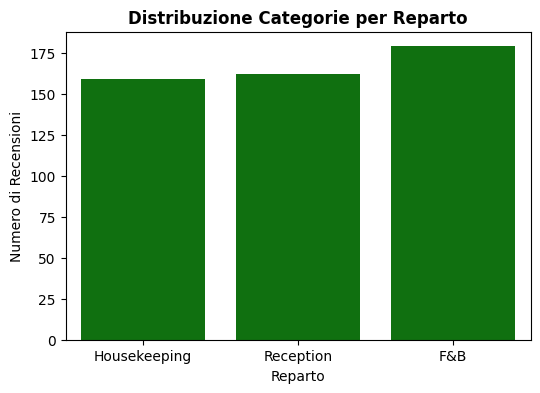

CONTEGGIO TOTALE DELLA COLONNA: department
F&B             179
Reception       162
Housekeeping    159
Name: count, dtype: int64


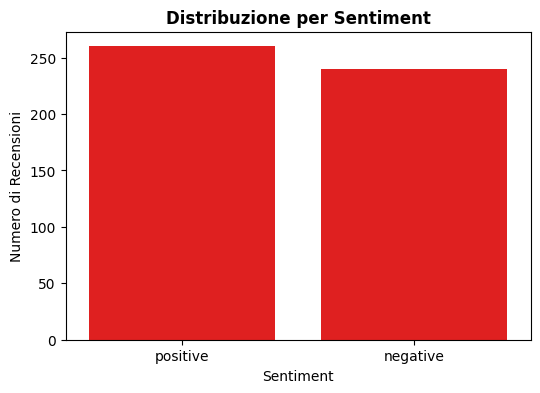

CONTEGGIO TOTALE DELLA COLONNA: sentiment
positive    260
negative    240
Name: count, dtype: int64


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x="department", data=df , color="green") #impostazioni colonne e righe con annesso colore
plt.title("Distribuzione Categorie per Reparto",fontweight='bold') #titolo del grafico con un font scuro ( grassetto)
plt.xlabel("Reparto")
plt.ylabel("Numero di Recensioni")
plt.show()

print('CONTEGGIO TOTALE DELLA COLONNA:',df['department'].value_counts()) #conteggio numerico delle categorie per reparto

print("=" * 70) #separazione per i grafici
print("=" * 70)

plt.figure(figsize=(6, 4))
sns.countplot(x="sentiment", data=df , color="red") #impostazioni colonne e righe con annesso colore
plt.title("Distribuzione per Sentiment",fontweight='bold')#titolo del grafico con un font scuro ( grassetto)
plt.xlabel("Sentiment")
plt.ylabel("Numero di Recensioni")
plt.show()

print('CONTEGGIO TOTALE DELLA COLONNA:',df['sentiment'].value_counts()) #conteggio numerico riguardante il sentiment di ogni categoria

Unisco la colonna TITLE con BODY come da traccia aggiungendo uno spazio vuoto per non incollare effettivamente l'ultima parola della prima colonna con la prima parola della seconda colonna. Definisco le variabili di input e taget utili per i passaggi futuri riguardanti l'addestramento ( Train/Test ) .

In [5]:
df['text_combinated']=df['title']+ " " + df['body']

x=df['text_combinated']
y_reparto=df['department']
y_sentiment=df['sentiment']

Applicazione delle fasi di pulizia del testo usando una tokenizzazione base. Eliminazione di tutta la punteggiatura per ogni riga e ognuna di esse sarà tutta in minuscolo. Ciò importante per identificare e dare peso alle stesse parole. Esempio :("Casa" e "casa ) sono la stesa parola, ma se non usassimo la funzione citata prima , il modello non le identificherà uguali, e quindi assegnerà un peso diverso a entrambi.

In [6]:


x_pulito=x.str.lower()

definizione_punteggiatura=str.maketrans('','',string.punctuation)

x_pulito=x_pulito.str.translate(definizione_punteggiatura)

print('PRIMA DELLA PULIZIA \n',x.iloc[465]) #usiamo la funzione iloc per visualizzare e stampare a schermo ( in questo caso la 10 recensione)

print('DOPO LA PULIZIA \n',x_pulito.iloc[465]) #stesso identico passaggio di prima ma questa volta adottando la pulizia sulla frase

PRIMA DELLA PULIZIA 
 RICETIONIST INCOMPETENTE!! CONTO SBAGLIATO COMPLETAMENTE!!?? Qual'è il senso di un gestionale se la ricetionist non sa usarlo?? Al check-out mi presentò una fattura CON QUATTRO ADDEBITI ERRATI e rispose male quando lo segnalai!! Servvizio INDECENTE!!$$ #checkoutfail @direzione
DOPO LA PULIZIA 
 ricetionist incompetente conto sbagliato completamente qualè il senso di un gestionale se la ricetionist non sa usarlo al checkout mi presentò una fattura con quattro addebiti errati e rispose male quando lo segnalai servvizio indecente checkoutfail direzione


Dalla libreria SKLEARN utilizziamo il ***train test split***.Tecnica fondamentale nel machine learning per valutare le prestazioni di un modello. Si divide il dataset per addestrare il modello e permettergli di apprendere le regole(Train set) e infine si verifica l'accuratezza del modello sui dati mai visti prima ( Test set). Cio e' importante farlo anche dividendo il dataset secondo delle percentuali 80% per l'addestramento e 20% per la parte di test finale.

In [7]:


#addestramento per reparto, con percentuali 80 e 20, impostazione random state (seme)con 42 per generare numeri casuaili e stratify
#per bilanciare la divisione dei dati in base a una specifica colonna ( in questo caso quella del reparto)
x_train_rep,x_test_rep,y_train_rep,y_test_rep=train_test_split(x_pulito,y_reparto,test_size=0.2,random_state=42,stratify=y_reparto)

#addestramento per sentiment, steso discorso logico per quello di prima , con colonna diversa( quella che riguarda il sentiment)
x_train_sent,x_test_sent,y_train_sent,y_test_sent=train_test_split(x_pulito,y_sentiment,test_size=0.2,random_state=42,stratify=y_sentiment)


Dalla libreria sklearn utilizzo il CountVectorizer. Il machine learning non può lavorare direttamente con dati testuali e non strutturati, quindi bisogna prendere i nostri testi e trasformarli in numeri,vettori. Come possiamo farlo? Ci sono varie possibilità, in questa caso andrò a utilizzare ***Bag of Words***, modello usato nel NLP( Natural Language Processing ) per rappresentare i documenti ignorando l'ordine delle parole. Gli elementi fondamentali sono due, ovvero il dizionario delle parole e misura per pesare la presenza delle parole nei documenti. Vengono usate di solito, misure come CountVectorizer e TF-IDF.

In [8]:
#vettorizzazione del testo con Bag of word usando la misura count vectorizer


#vettorizzazione reparto e sentiment con unigrammi
vettorizzazione_rep=CountVectorizer(ngram_range=(1,1))# estrae la prima parola, indica lunghezza minima da considerare e la lunghezza massima da considerare
vettorizzazione_sent=CountVectorizer(ngram_range=(1,1))

#fit transform usato per creare il nostro "dizionario" di parole. Aggiunge un numero indice a ciascuna parola. Va fatto
# ESCLUSIVAMENTE sulla parte di train test per evitare problemi di data leakage

x_train_rep_vettori=vettorizzazione_rep.fit_transform(x_train_rep)
x_train_sent_vettori=vettorizzazione_sent.fit_transform(x_train_sent)

#qui si usa solo transform senza l'aggiunta di fit. Ovvero si prende il vocabolario creato precedentente e si trasforma il testo in vettori.

x_test_rep_vettori=vettorizzazione_rep.transform(x_test_rep)
x_test_sent_vettori=vettorizzazione_sent.transform(x_test_sent)



***SCELTA DEL MODELLO***. Per questo progetto, sia per il PoC_1 e il PoC_2 sono stati utilizzati due tipi di algoritimi. Per la classificazione del reparto ho usato e importato dalla libreria **Skelarn** il modello **MUltinomial_Naive_Bayes**, utile appunto per problemi di classificazione di testo, reparto, categorie ecc. Per il sentiment, ho utilizzato , sempre importando dalla libreria **sklearn**, la **LogisticRegression** ( Regressione logistica ), anche lui molto utilizzato per problemi di classificazione, in particolare quella binaria, e quindi in questo caso a prevedere etichette discrete , come appunto il sentiment ( negativo o positivo )

In [9]:
#usiamo gli algoritmi per raddestrare i modelli , per il reparto useremo naive bayses per il sentiment la regressione logistica

#Multinomial Naive Bayes per predizione reparto
#LogisticRegression per predizione sentiment

modello_reparto=MultinomialNB()
modello_sentiment=LogisticRegression()

modello_reparto.fit(x_train_rep_vettori,y_train_rep)
modello_sentiment.fit(x_train_sent_vettori,y_train_sent)

print("\n  L'addestramento del PoC_1 e' stato completato")


  L'addestramento del PoC_1 e' stato completato


***VALUTAZIONE PRESTAZIONI***: Una volta addestrato il modello, si passa alla fase di valutazione delle sue prestazioni attraverso appunto delle metriche. Dalla libreria **Sklearn** si importa **Accuracy_score** per capire quanto il modello è "Performante" (più il risultato è alto, più e' preciso ) e **Classificaziotion_report** utile per andare ad analizzare le metriche come la **Precision**, la **Recall** e l'**F1_score**.


Qui andrò a valutare sia le metriche di perfomance per il Train set e sia per il Test set, in modo tale da confrotarle e fare ulteriori considerazioni aggiuntive.

In [10]:


predizione_reparto=modello_reparto.predict(x_test_rep_vettori) #passiamoquesta volta il test set sia per il reparto che per il sentiment
predizione_sentiment=modello_sentiment.predict(x_test_sent_vettori)

accuracy_rep=accuracy_score(y_test_rep,predizione_reparto) #Y-test di reparto e sentiment sono le etichette reali che si andranno a confrontare con predizione reparto e sentiment
accuracy_sent=accuracy_score(y_test_sent,predizione_sentiment)

#calcolo e stampa report di reparto e la sua accuracy
print("PERFORMANCE REPARTO CON TEST SET SUL POC_1")
print(f"Accuracy Totale: {accuracy_rep:.4f}")
print("\nReport Dettagliato:")
print(classification_report(y_test_rep, predizione_reparto))

#calcolo e stampa report del sentiment e la sua accuracy
print("PERFORMANCE SENTIMENT CON TEST SET SUL POC_1")
print(f"Accuracy Totale: {accuracy_sent:.4f}")
print("\nReport Dettagliato:")
print(classification_report(y_test_sent, predizione_sentiment))


PERFORMANCE REPARTO CON TEST SET SUL POC_1
Accuracy Totale: 0.9900

Report Dettagliato:
              precision    recall  f1-score   support

         F&B       1.00      0.97      0.99        36
Housekeeping       0.97      1.00      0.98        32
   Reception       1.00      1.00      1.00        32

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100

PERFORMANCE SENTIMENT CON TEST SET SUL POC_1
Accuracy Totale: 0.9700

Report Dettagliato:
              precision    recall  f1-score   support

    negative       0.96      0.98      0.97        48
    positive       0.98      0.96      0.97        52

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



In [11]:
#Perfomance effettuate sul train set

predizione_reparto_train=modello_reparto.predict(x_train_rep_vettori)
predizione_sentiment_train=modello_sentiment.predict(x_train_sent_vettori)

accuracy_rep=accuracy_score(y_train_rep,predizione_reparto_train)

#calcolo e stampa report di reparto e la sua accuracy
print("PERFORMANCE REPARTO CON TRAIN SET SUL POC_1")
print(f"Accuracy Totale: {accuracy_rep:.4f}")
print("\nReport Dettagliato:")
print(classification_report(y_train_rep, predizione_reparto_train))

#calcolo e stampa report del sentiment e la sua accuracy
print("PERFORMANCE SENTIMENT CON TRAIN SET SUL POC_1")
print(f"Accuracy Totale: {accuracy_sent:.4f}")
print("\nReport Dettagliato:")
print(classification_report(y_train_sent, predizione_sentiment_train))


PERFORMANCE REPARTO CON TRAIN SET SUL POC_1
Accuracy Totale: 0.9950

Report Dettagliato:
              precision    recall  f1-score   support

         F&B       0.99      0.99      0.99       143
Housekeeping       1.00      1.00      1.00       127
   Reception       0.99      0.99      0.99       130

    accuracy                           0.99       400
   macro avg       1.00      1.00      1.00       400
weighted avg       0.99      0.99      0.99       400

PERFORMANCE SENTIMENT CON TRAIN SET SUL POC_1
Accuracy Totale: 0.9700

Report Dettagliato:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       192
    positive       1.00      1.00      1.00       208

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In questa fase, importantissima, ho deciso di testare il modello appena creato , per capire effettivamente se fosse cosi' perfomante. I risultati futuri andranno a mostrare che effettivamente non lo è. ( TUTTI I COMMENTI DEI RISULTATI SONO PRESENTI ALL'INTERNO DELLA STESURA DELLA TESI ).

Per testare il modello, ho assegnato delle nuove recensioni, anche ambigue, avviato un ciclo per applicare la pulizia del testo fatta in precedenza e la vettorizzazione dei nuovi testi e infine la predizione del reparto e del sentiment.

In [22]:
 # Scriviamo un elenco di nuove recensioni
nuove_recensioni = [
    "Non mi e' piaciuto cio che abbiamo mangiato al ristorante, non ci torno piu",
    "Colazione pessima, ma la pulizia delle camere e' stata perfetta, questo lo devo dire",
    "RECCEEPTIONNNS pERFEtta e sbalorditiva, complimenti hAI ragazzi DEl ufficio pPrincipale",
    "Accoglienza disastrosa al momento che abbiamo messo piede li",
    "prelibatezze a quantita industriale, quanto mangiare mamma mia, wow!!!!!!",
    "Questo viaggio e' stato molto lungo, ma al momento dell'arrivo in hotel, mi sono sentito felice, sono stato accolto davvero bene",
    "Frutta e contorni da rivedere, primi piatti scadenti",
    "che schifo, presenza di topi ,dovunque",
    "Esperienza negativa, personale del ristorante poco attento ai dettagli e molto scortese, non mi sono trovato bene qui."
]

In [18]:
#Converto in minuscolo e vado a rimuovere la punteggiatura come fatto con le recensioni del dataset
nuove_pulite = []
for testo in nuove_recensioni:
    testo_lower = testo.lower()
    # Rimuovo la punteggiatura base come fatto in precedenza
    testo_senza_punteggiatura = testo_lower.translate(str.maketrans('', '', string.punctuation))
    nuove_pulite.append(testo_senza_punteggiatura)

print("Nuovi testi pronti e puliti per il PoC 1:")
print(nuove_pulite) #stampa a schermo delle nuove recensioni pulite e senza punteggiatura.

Nuovi testi pronti e puliti per il PoC 1:
['non mi e piaciuto cio che abbiamo mangiato al ristorante non ci torno piu', 'colazione pessima ma la pulizia delle camere e stata perfetta questo lo devo dire', 'recceeptionnns perfetta e sbalorditiva complimenti hai ragazzi del ufficio pprincipale', 'accoglienza disastrosa al momento che abbiamo messo piede li', 'prelibatezze a quantita industriale quanto mangiare mamma mia wow', 'questo viaggio e stato molto lungo ma al momento dellarrivo in hotel mi sono sentito felice sono stato accolto davvero bene', 'tutto sommato qualità giusta e mangiare nella norma niente di particolare ma non posso lamentarmi', 'frutta e contorni da rivedere primi piatti scadenti', 'che schifo presenza di topi dovunque', 'esperienza negativa personale del ristorante poco attento ai dettagli e molto scortese non mi sono trovato bene qui']


In [19]:
#Trasformo le nuove frasi usando il vocabolario creato in precedenza per il PoC_1
nuovi_vettori_rep = vettorizzazione_rep.transform(nuove_pulite)
nuovi_vettori_sent = vettorizzazione_sent.transform(nuove_pulite)

In [20]:
#Generazione predizione reparto e sentiment
predizioni_nuovo_rep = modello_reparto.predict(nuovi_vettori_rep)
predizioni_nuovo_sent = modello_sentiment.predict(nuovi_vettori_sent)

Ciclo test di verifica delle nuove recensioni con predizione reparto e sentiment.

In [23]:

print("TEST DI VERIFICA SUL POC 1\n")
for i in range(len(nuove_recensioni)):
    print(f"Recensione originale: '{nuove_recensioni[i]}'") #inserimento nuove recensioni
    print(f"Predizione Reparto:  [{predizioni_nuovo_rep[i]}]") #pred reparto
    print(f"Predizione Sentiment:[{predizioni_nuovo_sent[i]}]") #pred sentiment
    print("-" * 100)

TEST DI VERIFICA SUL POC 1

Recensione originale: 'Non mi e' piaciuto cio che abbiamo mangiato al ristorante, non ci torno piu'
Predizione Reparto:  [F&B]
Predizione Sentiment:[negative]
----------------------------------------------------------------------------------------------------
Recensione originale: 'Colazione pessima, ma la pulizia delle camere e' stata perfetta, questo lo devo dire'
Predizione Reparto:  [F&B]
Predizione Sentiment:[negative]
----------------------------------------------------------------------------------------------------
Recensione originale: 'RECCEEPTIONNNS pERFEtta e sbalorditiva, complimenti hAI ragazzi DEl ufficio pPrincipale'
Predizione Reparto:  [Housekeeping]
Predizione Sentiment:[negative]
----------------------------------------------------------------------------------------------------
Recensione originale: 'Accoglienza disastrosa al momento che abbiamo messo piede li'
Predizione Reparto:  [F&B]
Predizione Sentiment:[negative]
------------------

**CONFUSION MATRIX (Matrice di confusione)**:

Strumento visivo a livello grafico per valutare le prestazioni di un modello di classificazione. In questo caso l'ho utilizato sia per le prestazioni del modello riguardante il reparto e per il modello riguardante il sentiment.

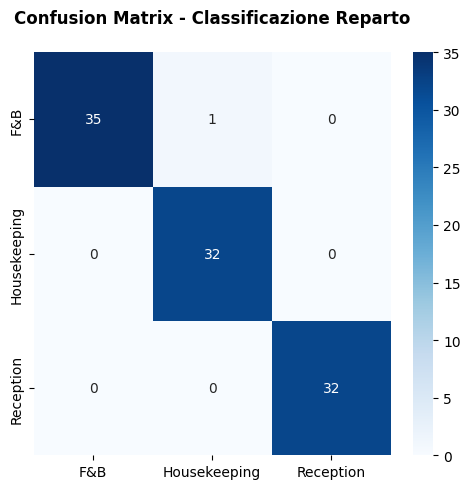

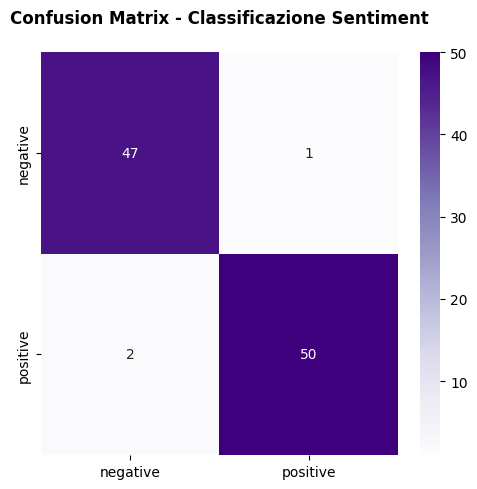

In [17]:


labels_reparto=modello_reparto.classes_ #recupero delle classi per il reparto e garantisce l'ordine di queste ultime

plt.figure(figsize=(5,5)) #dimensione della finestra grafica
sns.heatmap(confusion_matrix(y_test_rep, predizione_reparto , labels=labels_reparto), #mappa colorata, utilizzo di confusion matrix con y test del reparto e la sua predizione
            annot=True, fmt="d",cmap="Blues", #attivazione scrittura numeri all'interno dei quadrati,numeri interi e colorazione blu
            xticklabels=labels_reparto, #assegnazione classi reali righe asse y e righe asse x anzichè di vedere solo numeri
            yticklabels=labels_reparto,),

plt.title("Confusion Matrix - Classificazione Reparto\n", fontsize=12, fontweight='bold')
plt.tight_layout() #regolazione automatica per non sovrapporre nulla
plt.show()

print("="*62)
print("="*62)

labels_sentiment=modello_sentiment.classes_ #recupero delle classi per il reparto e garantisce l'ordine di queste ultime

plt.figure(figsize=(5,5)) #dimensione della finestra grafica
sns.heatmap(confusion_matrix(y_test_sent, predizione_sentiment, labels=labels_sentiment), #mappa colorata, utilizzo di confusion matrix con y test del sentiment e la sua predizione
            annot=True, fmt="d",cmap="Purples", #attivazione scrittura numeri all'interno dei quadrati,numeri interi e colorazione viola
            xticklabels=labels_sentiment, #assegazione classi reali sulle labels y e x
            yticklabels=labels_sentiment,),


plt.title("Confusion Matrix - Classificazione Sentiment\n", fontsize=12, fontweight='bold')
plt.tight_layout() #regolazione automatica per non sovrapporre nulla
plt.show()